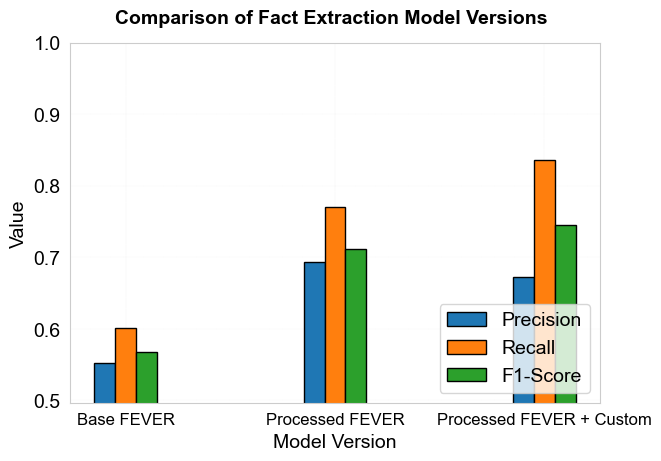

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==============================================================================
# 1. USER-DEFINED DATA
# ==============================================================================
# Define the models
MODELS = ['Base FEVER', 'Processed FEVER', 'Processed FEVER + Custom']

# Define the performance metrics for each model
# Values should be lists of the same length as MODELS
PRECISION = [0.552, 0.693, 0.673]
RECALL = [0.601, 0.77, 0.836]
F1_SCORE = [0.568, 0.711, 0.745]

# The standard deviation/error variables have been removed.
# ==============================================================================


# --- 2. Set Global Aesthetic Parameters ---
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'font.family': 'sans-serif',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'grid.linestyle': '--',
    'grid.linewidth': 0.1,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'figure.titlesize': 16,
})

def create_grouped_bar_plot():
    # Number of models and metrics
    N_models = len(MODELS)
    bar_width = 0.1 # Width of each individual bar
    
    # Set the position of the bars on the X-axis
    ind = np.arange(N_models) # Group center positions
    
    # Calculate bar positions for each metric (Precision, Recall, F1)
    pos_precision = ind - bar_width
    pos_recall = ind
    pos_f1 = ind + bar_width

    # --- 3. Create Figure and Plot ---
    fig, ax = plt.subplots(figsize=(6.5, 4.5), constrained_layout=True)

    fig.suptitle('Comparison of Fact Extraction Model Versions', fontsize=14, fontweight='bold')

    # Plot 1: Precision (Note: yerr and capsize are removed)
    ax.bar(
        pos_precision, 
        PRECISION, 
        bar_width, 
        label='Precision', 
        color='#1f77b4', # Blue
        edgecolor='black'
    )

    # Plot 2: Recall (Note: yerr and capsize are removed)
    ax.bar(
        pos_recall, 
        RECALL, 
        bar_width, 
        label='Recall', 
        color='#ff7f0e', # Orange
        edgecolor='black'
    )

    # Plot 3: F1-Score (Note: yerr and capsize are removed)
    ax.bar(
        pos_f1, 
        F1_SCORE, 
        bar_width, 
        label='F1-Score', 
        color='#2ca02c', # Green
        edgecolor='black'
    )
    
    # --- 4. Finalizing Plot Aesthetics ---
    
    # Set X-axis labels to be the model names, centered on the group
    ax.set_xticks(ind)
    ax.set_xticklabels(MODELS)
    ax.set_xlabel('Model Version')
    
    # Set Y-axis label and limits 
    ax.set_ylabel('Value')
    # Use max() and min() across all data to set appropriate limits
    all_data = PRECISION + RECALL + F1_SCORE
    min_val = min(all_data) * 0.9
    ax.set_ylim(min_val, 1.0)
    
    # Add legend
    ax.legend(loc='lower right', frameon=True)
    
    # Add grid lines for easier value comparison
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 5. Saving the Figure ---
    plt.savefig('fact-extraction.png', format='png', dpi=300, bbox_inches='tight')
    plt.show()

# Execute the function
create_grouped_bar_plot()